<a href="https://colab.research.google.com/github/GUEST72/CSC311-Machine-Learning-projects/blob/main/assignment_2/Logic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data handling & preprocessing
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix


# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
transform =transforms.ToTensor()
mnist_full=datasets.MNIST(root='./data',train=True,download=True,transform=transform)

# Filter for only digits 0 and 1
binary_indices = (mnist_full.targets == 0) | (mnist_full.targets == 1)
mnist_binary = Subset(mnist_full, np.where(binary_indices)[0])

targets = np.array(mnist_binary.dataset.targets)[binary_indices]
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
train_idx, temp_idx = next(sss1.split(np.zeros(len(targets)), targets))

temp=targets[temp_idx]
sss2=StratifiedShuffleSplit(n_splits=1,test_size=0.5,random_state=42)
val_idx_rel,test_idx_rel=next(sss2.split(np.zeros(len(temp)),temp))


val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

train_set = Subset(mnist_binary, train_idx)
val_set   = Subset(mnist_binary, val_idx)
test_set  = Subset(mnist_binary, test_idx)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=64, shuffle=False)

In [ ]:
class LogisticRegressionScratch ( nn.Module):
  def __init__(self,num_features=28*28):
      super().__init__()
      self.W=nn.Parameter(torch.randn(num_features)*0.01)
      self.b=nn.Parameter(torch.zeros(1))


  def forward(self,x):
        x = x.view(x.size(0), -1)  # Flatten
        return torch.sigmoid(x @ self.W + self.b)

In [ ]:
def accuracy_binary(logits, yb):
    preds = (logits > 0.5).long()
    return (preds == yb).float().mean()


def train_binary_logreg(model, train_loader, val_loader, epochs=20, learning_rate=0.01, patience=3):
    opt = torch.optim.SGD(model.parameters(), lr=learning_rate)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # --- Early stopping variables ---
    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss, total_acc, total_samples = 0, 0, 0
        for xb, yb in train_loader:
            logits = model(xb)
            loss = F.binary_cross_entropy(logits, yb.float())

            opt.zero_grad()
            loss.backward()
            opt.step()

            bs = xb.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy_binary(logits, yb) * bs
            total_samples += bs

        train_losses.append(total_loss / total_samples)
        train_accs.append(total_acc / total_samples)

        # --- Validation ---
        model.eval()
        val_loss, val_acc, val_samples = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = F.binary_cross_entropy(logits, yb.float())
                bs = xb.size(0)
                val_loss += loss.item() * bs
                val_acc  += accuracy_binary(logits, yb) * bs
                val_samples += bs

        val_losses.append(val_loss / val_samples)
        val_accs.append(val_acc / val_samples)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={train_losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f}, "
              f"Val Loss={val_losses[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

        # --- Early stopping check ---
        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            print(f"  Patience counter {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("⏹ Early stopping triggered!")
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)  # restore best weights
                break

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
model = LogisticRegressionScratch()
train_losses, val_losses, train_accs, val_accs = train_binary_logreg(model,train_loader,val_loader,epochs=20,learning_rate=0.01, patience=3)


Epoch 1: Train Loss=0.2312, Train Acc=0.9901, Val Loss=0.1060, Val Acc=0.9964
Epoch 2: Train Loss=0.0777, Train Acc=0.9971, Val Loss=0.0630, Val Acc=0.9964
Epoch 3: Train Loss=0.0516, Train Acc=0.9971, Val Loss=0.0469, Val Acc=0.9972
Epoch 4: Train Loss=0.0399, Train Acc=0.9972, Val Loss=0.0383, Val Acc=0.9972
Epoch 5: Train Loss=0.0332, Train Acc=0.9975, Val Loss=0.0329, Val Acc=0.9972
Epoch 6: Train Loss=0.0288, Train Acc=0.9975, Val Loss=0.0292, Val Acc=0.9972
Epoch 7: Train Loss=0.0257, Train Acc=0.9976, Val Loss=0.0264, Val Acc=0.9972
Epoch 8: Train Loss=0.0233, Train Acc=0.9978, Val Loss=0.0243, Val Acc=0.9972
Epoch 9: Train Loss=0.0215, Train Acc=0.9979, Val Loss=0.0226, Val Acc=0.9972
Epoch 10: Train Loss=0.0200, Train Acc=0.9979, Val Loss=0.0212, Val Acc=0.9972
Epoch 11: Train Loss=0.0187, Train Acc=0.9979, Val Loss=0.0200, Val Acc=0.9972
Epoch 12: Train Loss=0.0177, Train Acc=0.9979, Val Loss=0.0190, Val Acc=0.9972
Epoch 13: Train Loss=0.0168, Train Acc=0.9979, Val Loss=0.018

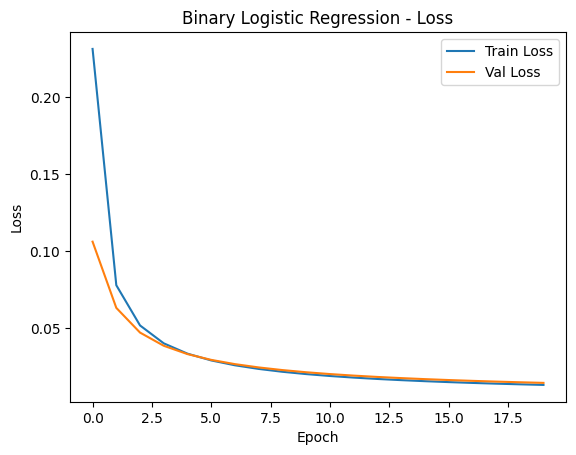

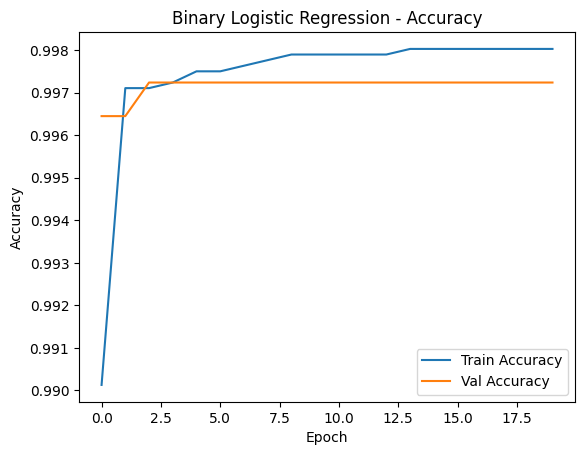

Final Test Accuracy: 0.9968


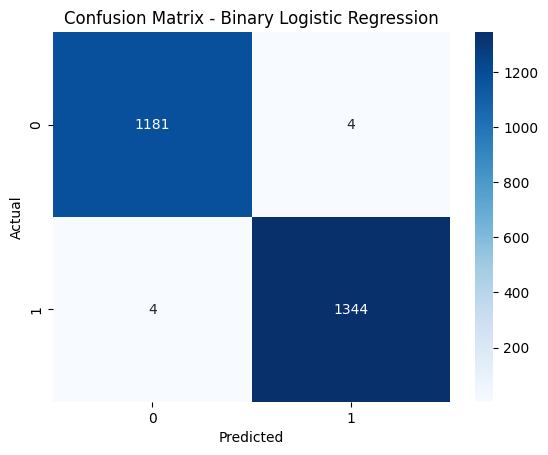

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Binary Logistic Regression - Loss")
plt.show()

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Binary Logistic Regression - Accuracy")
plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)
        preds = (logits > 0.5).long()
        all_preds.extend(preds.numpy())
        all_labels.extend(y.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Final Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Binary Logistic Regression")
plt.show()

In [ ]:
Learning_rate=[0.001,0.01,0.1,1]
batch_sizes=[16,32,64,128]
bs_results_logic=[]
lr_results_Logic=[]
for lr in Learning_rate:
    train_loader=DataLoader(train_set,batch_size=64,shuffle=True)
    val_loader=DataLoader(val_set,batch_size=64,shuffle=False)
    model=LogisticRegressionScratch()
    train_losses, val_losses, train_accs, val_accs=train_binary_logreg(model,train_loader,val_loader,epochs=10,learning_rate=lr)
    lr_results_Logic.append(val_accs[-1])
for bs in batch_sizes:
    train_loader=DataLoader(train_set,batch_size=bs,shuffle=True)
    val_loader=DataLoader(val_set,batch_size=bs,shuffle=False)
    model=LogisticRegressionScratch()
    train_losses, val_losses, train_accs, val_accs=train_binary_logreg(model,train_loader,val_loader,epochs=10,learning_rate=0.1)
    bs_results_logic.append(val_accs[-1])



Epoch 1: Train Loss=0.5555, Train Acc=0.9193, Val Loss=0.4478, Val Acc=0.9901
Epoch 2: Train Loss=0.3804, Train Acc=0.9958, Val Loss=0.3272, Val Acc=0.9925
Epoch 3: Train Loss=0.2877, Train Acc=0.9964, Val Loss=0.2573, Val Acc=0.9941
Epoch 4: Train Loss=0.2312, Train Acc=0.9962, Val Loss=0.2123, Val Acc=0.9937
Epoch 5: Train Loss=0.1937, Train Acc=0.9962, Val Loss=0.1813, Val Acc=0.9945
Epoch 6: Train Loss=0.1670, Train Acc=0.9962, Val Loss=0.1587, Val Acc=0.9949
Epoch 7: Train Loss=0.1472, Train Acc=0.9963, Val Loss=0.1415, Val Acc=0.9953
Epoch 8: Train Loss=0.1318, Train Acc=0.9963, Val Loss=0.1279, Val Acc=0.9953
Epoch 9: Train Loss=0.1196, Train Acc=0.9964, Val Loss=0.1170, Val Acc=0.9953
Epoch 10: Train Loss=0.1097, Train Acc=0.9966, Val Loss=0.1080, Val Acc=0.9953
Epoch 1: Train Loss=0.2284, Train Acc=0.9914, Val Loss=0.1059, Val Acc=0.9961
Epoch 2: Train Loss=0.0778, Train Acc=0.9968, Val Loss=0.0632, Val Acc=0.9964
Epoch 3: Train Loss=0.0517, Train Acc=0.9970, Val Loss=0.0471, 

In [ ]:
plt.plot(Learning_rate,lr_results_Logic,label='Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Learning Rate vs Validation Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.plot(batch_sizes,bs_results_logic,label='Batch Size')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.title('Batch Size vs Validation Accuracy')
plt.legend()
plt.show()